# 04 — Modeling

This notebook fits two classifiers:

- Logistic Regression
- Random Forest

The goal is to predict whether a 2025 trending entry is high engagement (top quartile of likes-to-views ratio, threshold defined from 2024).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

BASE_DIR = Path(".")
df = pd.read_csv(BASE_DIR / "yt_project_outputs" / "analysis_row_level.csv", parse_dates=["snapshot_date", "publish_date"])

In [2]:
model_df = df[np.isfinite(df["likes_to_views_ratio"])].copy()
cap = model_df["likes_to_views_ratio"].quantile(0.999)
model_df["likes_to_views_ratio"] = model_df["likes_to_views_ratio"].clip(upper=cap)

train = model_df[model_df["year"] == 2024].copy()
test = model_df[model_df["year"] == 2025].copy()

threshold = train["likes_to_views_ratio"].quantile(0.75)
train["high_engagement"] = (train["likes_to_views_ratio"] >= threshold).astype(int)
test["high_engagement"] = (test["likes_to_views_ratio"] >= threshold).astype(int)

features = [
    "country", "language_clean", "publish_weekday", "publish_hour_utc", "publish_month",
    "title_length", "description_length", "uppercase_ratio", "exclamation_count",
    "question_count", "hashtag_count", "tag_count"
]
categorical_features = ["country", "language_clean", "publish_weekday"]
numeric_features = [c for c in features if c not in categorical_features]

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
])

X_train = train[features]
y_train = train["high_engagement"]
X_test = test[features]
y_test = test["high_engagement"]

In [3]:
logit_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced")),
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=80,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_depth=15,
        min_samples_leaf=10,
    )),
])

logit_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'language_clean',
                                                   'publish_weekday']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['publish_hour_utc',
                                                   'publish_month',
                                                   'title_length',
                                                   'description_length',
                                                   'uppercase_ratio',
                                                   'exclamation_count',
                                                   'question_count',
                                                   'hashtag_count',
                                                   'tag_count'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=15, min_samples_leaf=10,
                                        n_estimators=80, n_jobs=-1,
                                        random_state=42))])

In [4]:
logit_prob = logit_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
logit_pred = (logit_prob >= 0.5).astype(int)
rf_pred = (rf_prob >= 0.5).astype(int)

metrics_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_test, logit_prob),
        "avg_precision": average_precision_score(y_test, logit_prob),
        "accuracy": accuracy_score(y_test, logit_pred),
        "precision": precision_score(y_test, logit_pred),
        "recall": recall_score(y_test, logit_pred),
        "f1": f1_score(y_test, logit_pred),
    },
    {
        "model": "Random Forest",
        "roc_auc": roc_auc_score(y_test, rf_prob),
        "avg_precision": average_precision_score(y_test, rf_prob),
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision": precision_score(y_test, rf_pred),
        "recall": recall_score(y_test, rf_pred),
        "f1": f1_score(y_test, rf_pred),
    }
]).round(4)

metrics_df

,model,roc_auc,avg_precision,accuracy,precision,recall,f1
0,Logistic Regression,0.7004,0.3666,0.6045,0.294,0.7086,0.4156
1,Random Forest,0.7143,0.3792,0.6375,0.313,0.6917,0.4310


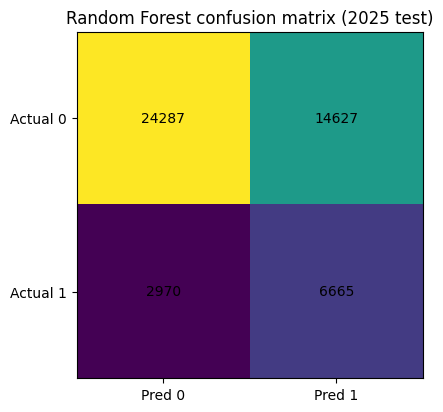

In [5]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4.5))
plt.imshow(cm)
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])
plt.title("Random Forest confusion matrix (2025 test)")
plt.show()

In [6]:
pred_df = test[["video_id", "country", "snapshot_date", "likes_to_views_ratio", "title"]].copy()
pred_df["actual_high_engagement"] = y_test.values
pred_df["pred_prob_rf"] = rf_prob

deciles = pd.qcut(pred_df["pred_prob_rf"], 10, labels=[f"D{i}" for i in range(1, 11)])
decile_summary = pred_df.groupby(deciles, observed=False).agg(
    rows=("actual_high_engagement", "size"),
    actual_rate=("actual_high_engagement", "mean"),
    avg_pred=("pred_prob_rf", "mean"),
).reset_index()

decile_summary

,pred_prob_rf,rows,actual_rate,avg_pred
0,D1,4855,0.043460,0.259144
1,D2,4855,0.076828,0.350382
2,D3,4855,0.098043,0.398988
3,D4,4856,0.137150,0.438807
4,D5,4854,0.141121,0.470437
5,D6,4854,0.188710,0.497088
6,D7,4855,0.229454,0.521764
7,D8,4855,0.283007,0.549364
8,D9,4855,0.339238,0.594922
9,D10,4855,0.447580,0.682645


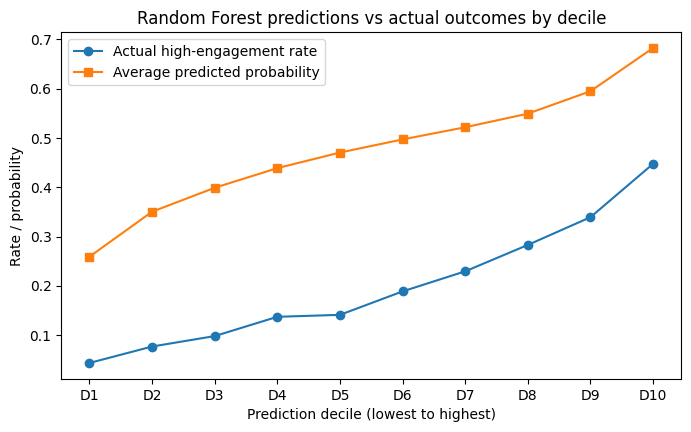

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(decile_summary.iloc[:, 0].astype(str), decile_summary["actual_rate"], marker="o", label="Actual high-engagement rate")
plt.plot(decile_summary.iloc[:, 0].astype(str), decile_summary["avg_pred"], marker="s", label="Average predicted probability")
plt.title("Random Forest predictions vs actual outcomes by decile")
plt.xlabel("Prediction decile (lowest to highest)")
plt.ylabel("Rate / probability")
plt.legend()
plt.show()

## Summary

The Random Forest outperforms the Logistic Regression on this task. In the executed run:

- **Random Forest ROC-AUC:** about **0.71**
- **Random Forest F1:** about **0.43**

This is a useful directional model for ranking likely high-engagement trending entries, but it is not strong enough to replace judgment or experimentation.